In [2]:
import numpy as np
import matplotlib.pyplot as plt
from keras.applications.vgg16 import VGG16, preprocess_input
from keras.preprocessing.image import load_img, img_to_array
from keras.models import Model

model = VGG16(weights="imagenet", include_top=True)

img = load_img("image.png", target_size=(224,224))
img = img_to_array(img)
img = np.expand_dims(img, axis=0)
img = preprocess_input(img)

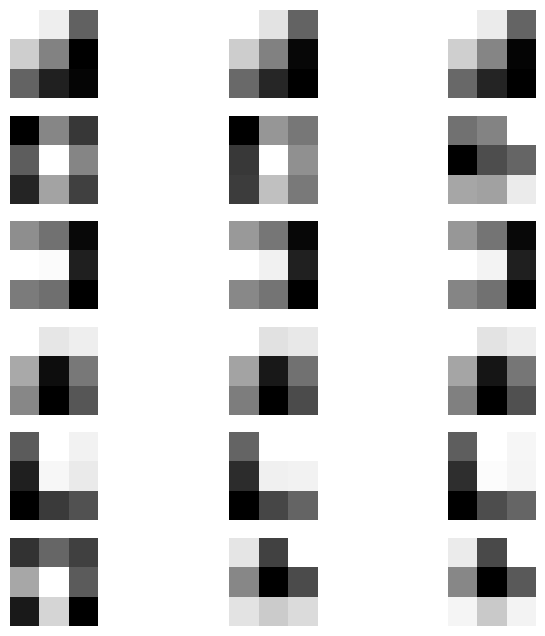

In [3]:
filters, _ = model.layers[1].get_weights()  # block1_conv1

f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

n_filters = 6
plt.figure(figsize=(8,8))
ix = 1
for i in range(n_filters):
    f = filters[:,:,:,i]
    for j in range(3):
        plt.subplot(n_filters,3,ix)
        plt.imshow(f[:,:,j], cmap="gray")
        plt.axis("off")
        ix += 1
plt.show()

In [4]:
layer_outputs = [layer.output for layer in model.layers if "conv" in layer.name]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

feature_maps = activation_model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


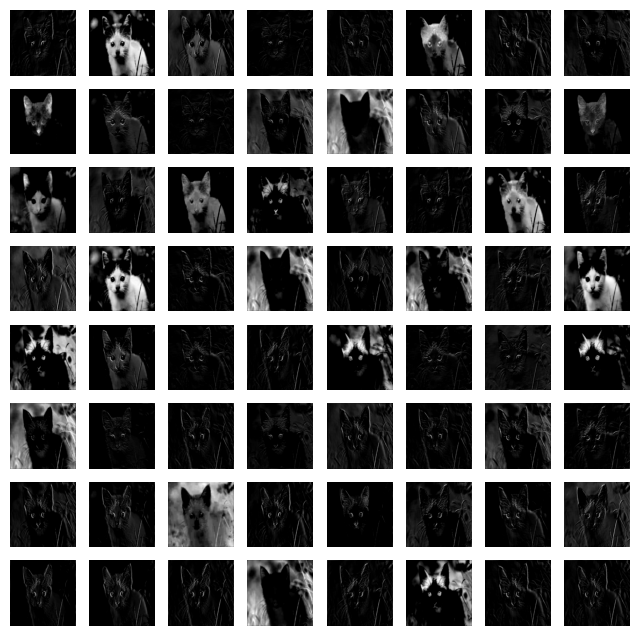

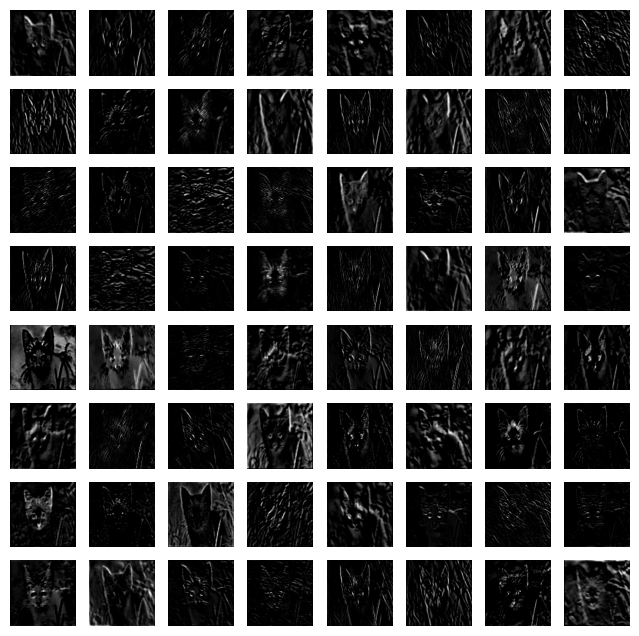

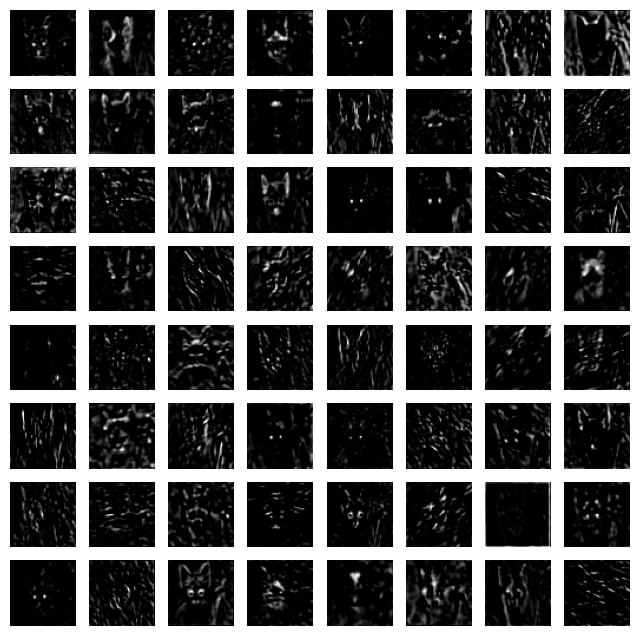

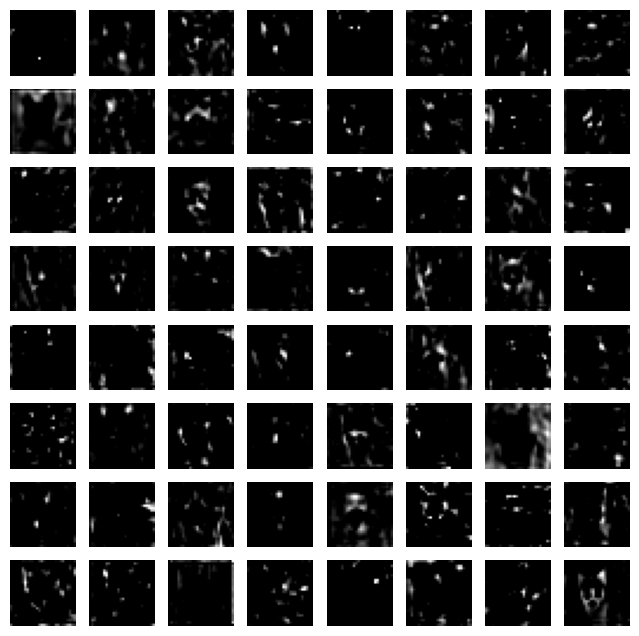

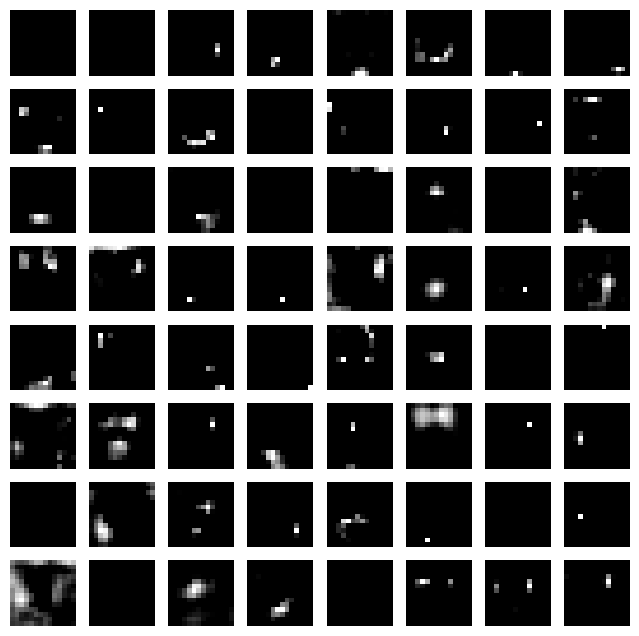

In [5]:
def plot_feature_maps(fmap, max_maps=64):
    n = int(np.sqrt(max_maps))
    plt.figure(figsize=(8,8))
    ix = 1
    for i in range(max_maps):
        plt.subplot(n,n,ix)
        plt.imshow(fmap[0,:,:,i], cmap="gray")
        plt.axis("off")
        ix += 1
    plt.show()

# visualize 5 blocks
for fmap in feature_maps[::3]:   # sample blocks
    plot_feature_maps(fmap)

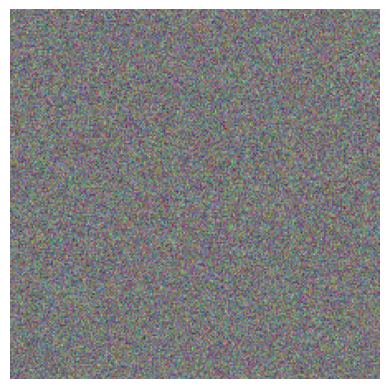

In [6]:
import tensorflow as tf

layer_name = "block5_conv3"
filter_index = 10

submodel = Model(model.input, model.get_layer(layer_name).output)

input_img = tf.Variable(tf.random.normal([1,224,224,3]))

optimizer = tf.keras.optimizers.Adam(10.0)

for i in range(30):
    with tf.GradientTape() as tape:
        act = submodel(input_img)
        loss = tf.reduce_mean(act[:,:,:,filter_index])
    grads = tape.gradient(loss, input_img)
    optimizer.apply_gradients([(grads, input_img)])

result = input_img.numpy()[0]
result = (result - result.min())/(result.max()-result.min())

plt.imshow(result)
plt.axis("off")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_23']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


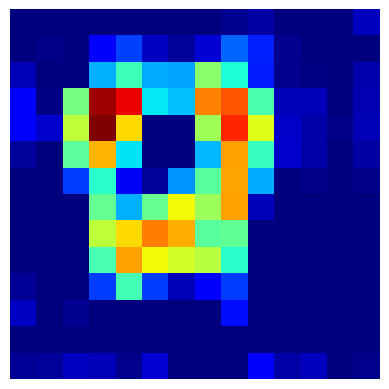

In [7]:
last_conv = model.get_layer("block5_conv3")
grad_model = Model(model.inputs, [last_conv.output, model.output])

with tf.GradientTape() as tape:
    conv_out, preds = grad_model(img)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, conv_out)
weights = tf.reduce_mean(grads, axis=(1,2))

cam = tf.reduce_sum(weights[:,None,None,:] * conv_out, axis=-1)
cam = np.maximum(cam[0],0)
cam /= cam.max()

plt.imshow(cam, cmap="jet")
plt.axis("off")
plt.show()

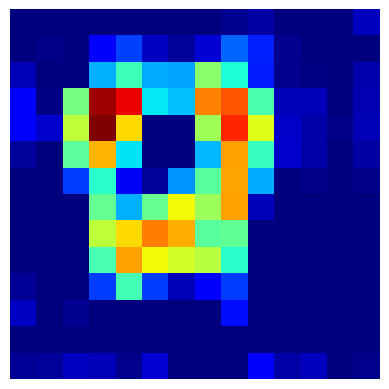

In [8]:
last_conv = model.get_layer("block5_conv3")
grad_model = Model(model.inputs, [last_conv.output, model.output])

with tf.GradientTape() as tape:
    conv_out, preds = grad_model(img)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, conv_out)
weights = tf.reduce_mean(grads, axis=(1,2))

cam = tf.reduce_sum(weights[:,None,None,:] * conv_out, axis=-1)
cam = np.maximum(cam[0],0)
cam /= cam.max()

plt.imshow(cam, cmap="jet")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

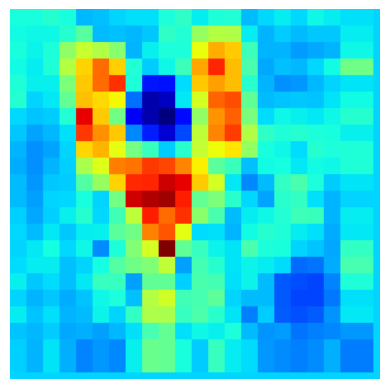

In [9]:
def occlusion_map(img, size=20, stride=10):
    h,w,_ = img.shape
    heat = np.zeros((h,w))
    base = model.predict(img[None])[0].max()

    for y in range(0,h-size,stride):
        for x in range(0,w-size,stride):
            occluded = img.copy()
            occluded[y:y+size, x:x+size] = 0
            p = model.predict(occluded[None])[0].max()
            heat[y:y+size, x:x+size] = base - p
    return heat

heat = occlusion_map(img[0])
plt.imshow(heat, cmap="jet")
plt.axis("off")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

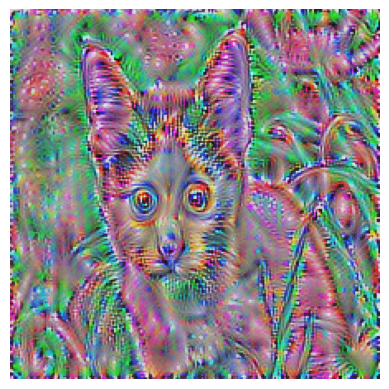

In [10]:
target_layer = "block3_conv3"
feat_model = Model(model.input, model.get_layer(target_layer).output)
target_feat = feat_model(img)

recon = tf.Variable(tf.random.normal([1,224,224,3]))
opt = tf.keras.optimizers.Adam(0.05)

for _ in range(200):
    with tf.GradientTape() as tape:
        feat = feat_model(recon)
        loss = tf.reduce_mean((feat - target_feat)**2)
    grads = tape.gradient(loss, recon)
    opt.apply_gradients([(grads, recon)])

out = recon.numpy()[0]
out = (out-out.min())/(out.max()-out.min())
plt.imshow(out); plt.axis("off")

In [15]:
layer = model.get_layer("block5_conv3")
feat = Model(model.input, layer.output).predict(img)

importance = feat.mean(axis=(1,2))[0]
top = importance.argsort()[-5:]
print(top)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[353 446  45 355 286]


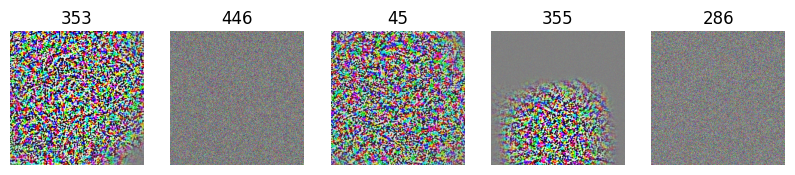

In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Model

layer_name = "block5_conv3"
submodel = Model(model.input, model.get_layer(layer_name).output)

def visualize_channel(idx, steps=40, lr=5.0):
    img_var = tf.Variable(tf.random.normal([1,224,224,3]))
    opt = tf.keras.optimizers.Adam(lr)

    for _ in range(steps):
        with tf.GradientTape() as tape:
            act = submodel(img_var)
            loss = tf.reduce_mean(act[:,:,:,idx])
        grads = tape.gradient(loss, img_var)
        opt.apply_gradients([(grads, img_var)])

    out = img_var.numpy()[0]
    out = (out-out.min())/(out.max()-out.min())
    return out

channels = [353,446,45,355,286]

plt.figure(figsize=(10,4))
for i,c in enumerate(channels):
    plt.subplot(1,len(channels),i+1)
    plt.imshow(visualize_channel(c))
    plt.title(str(c))
    plt.axis("off")
plt.show()